# 🧹 The Complete Data Preprocessing Guide for Machine Learning

**A hands-on, theory + code guide for cleaning, transforming and preparing any dataset for Machine Learning.**

This notebook is built so that a complete beginner can *learn* preprocessing step by step, and a working
data analyst / ML practitioner can *reuse* it as a reference cookbook on real projects.

Every section follows the same pattern:

1. **Theory** — what the technique is and *why* it exists (in plain English)
2. **When to use it** — the practical decision rules used in industry
3. **Code** — runnable, heavily commented code you can copy into your own project
4. **Pitfalls** — mistakes beginners (and experienced people!) make

---

## 📚 Table of Contents

1. [What is Data Preprocessing & Why it Matters](#1)
2. [Environment Setup](#2)
3. [Step 0 — Explore Before You Clean (Mini-EDA)](#3)
4. [Handling Missing Values](#4)
5. [Handling Outliers](#5)
6. [Feature Scaling & Transformation](#6)
7. [Feature Encoding (Categorical → Numeric)](#7)
8. [Putting It All Together — A Real End-to-End Pipeline](#8)
9. [Preprocessing Checklist & Common Pitfalls](#9)
10. [Practice Exercises](#10)

---


<a id="1"></a>
## 1. What is Data Preprocessing & Why it Matters

**Data preprocessing** is the set of steps that turn raw, messy, real-world data into a clean,
consistent, numeric table that a Machine Learning model can actually learn from.

> 🗣️ **Industry truth:** In most real ML projects, 60–80% of the actual working time is spent on
> understanding and preprocessing data — not on model building. The model is often the easy part.

### The problems raw data almost always has

| Problem | Example | Section |
|---|---|---|
| **Missing values** | Age is blank for some passengers | Section 4 |
| **Outliers** | One customer's age is recorded as 500 | Section 5 |
| **Different scales** | `income` in the 10,000s, `age` in the tens | Section 6 |
| **Categorical (text) data** | `city = "Lahore"`, `gender = "Male"` | Section 7 |
| **Duplicates / wrong types / inconsistent formatting** | `"25"` (string) vs `25` (int) | Section 3 |

### The standard preprocessing pipeline

```
Raw Data
   │
   ▼
1. Explore (EDA)  →  understand shape, types, missingness, distributions
   │
   ▼
2. Clean          →  fix types, remove duplicates, handle missing values
   │
   ▼
3. Handle Outliers→  detect & treat extreme values
   │
   ▼
4. Transform/Scale→  bring numeric features to comparable ranges
   │
   ▼
5. Encode         →  convert categorical features to numbers
   │
   ▼
Model-Ready Data → Train/Test Split → Machine Learning Model
```

### ⚠️ The single most important rule in this whole notebook

> **Always split your data into train and test sets BEFORE you "fit" any preprocessing step**
> (imputer, scaler, encoder). Fit only on the training data, then use `.transform()` (not `.fit_transform()`)
> on the test data. This is called avoiding **data leakage** — letting information about the
> test set influence how you train. We will show this properly in Section 8.

For learning purposes, Sections 4–7 fit and transform on the whole dataset at once (simpler to follow),
but Section 8 shows the *correct*, leak-free, production-style pipeline.


<a id="2"></a>
## 2. Environment Setup

We'll use the standard Python data-science stack. `seaborn`'s built-in demo datasets
(`titanic`, `tips`) act as our real-world messy datasets throughout the guide, since they are
freely available and everyone can run this notebook without needing their own data.

Install any missing library by uncommenting the line below.


In [1]:
# !pip install pandas numpy matplotlib seaborn scikit-learn category_encoders scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")   # keep the notebook output clean of version-related warnings
%matplotlib inline

pd.set_option("display.max_columns", None)   # show all columns when printing dataframes
sns.set_style("whitegrid")

print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


<a id="3"></a>
## 3. Step 0 — Explore Before You Clean (Mini-EDA)

**Never preprocess blindly.** Before touching a single value, always ask:

1. What are the columns and their data types? (`df.info()`)
2. What does the data look like? (`df.head()`)
3. What's the statistical summary? (`df.describe()`)
4. Which columns have missing values, and how many? (`df.isnull().sum()`)
5. Are there duplicate rows? (`df.duplicated().sum()`)
6. What does each numeric column's distribution look like? (histograms)
7. Are there categorical columns, and how many unique values does each have?

Let's do this on the **Titanic** dataset — a classic, genuinely messy real-world dataset.


In [2]:
# Load a real, messy dataset
titanic = sns.load_dataset("titanic")

print("Shape (rows, columns):", titanic.shape)
titanic.head()


Shape (rows, columns): (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# 1. Data types and non-null counts
titanic.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [4]:
# 2. Statistical summary of numeric columns
titanic.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# 3. Missing values per column, sorted from most to least missing
titanic.isnull().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [6]:
# 4. Duplicate rows
print("Number of duplicate rows:", titanic.duplicated().sum())

# 5. Unique value counts for categorical-looking columns
categorical_cols = titanic.select_dtypes(include=["object", "category"]).columns
for col in categorical_cols:
    print(f"\n{col} -> {titanic[col].nunique()} unique values")
    print(titanic[col].value_counts(dropna=False).head())


Number of duplicate rows: 107

sex -> 2 unique values
sex
male      577
female    314
Name: count, dtype: int64

embarked -> 3 unique values
embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

class -> 3 unique values
class
Third     491
First     216
Second    184
Name: count, dtype: int64

who -> 3 unique values
who
man      537
woman    271
child     83
Name: count, dtype: int64

deck -> 7 unique values
deck
NaN    688
C       59
B       47
D       33
E       32
Name: count, dtype: int64

embark_town -> 3 unique values
embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64

alive -> 2 unique values
alive
no     549
yes    342
Name: count, dtype: int64


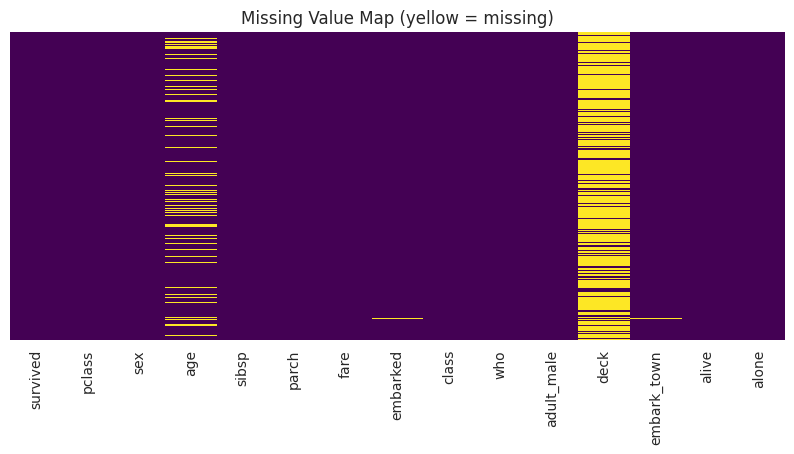

In [7]:
# 6. Visual check of missingness - a quick heatmap makes patterns easy to spot
plt.figure(figsize=(10, 4))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Value Map (yellow = missing)")
plt.show()


**What we learned from this mini-EDA (this is the thinking process you should repeat on any new dataset):**

- `deck` has ~77% missing → too much missing data to impute reliably, usually best to **drop the column**
- `age` has ~20% missing → a good candidate for **imputation** (Section 4)
- `embarked` / `embark_town` have 2 missing → tiny amount, safe to impute with the **mode**
- `sex`, `embarked`, `class`, `who`, `deck`, `embark_town`, `alive` are **categorical** → need **encoding** (Section 7)
- `fare` and `age` are on very different numeric scales → will need **scaling** (Section 6)
- We haven't checked for outliers yet → that's Section 5

This is exactly the order we'll now tackle the dataset in.


<a id="4"></a>
## 4. Handling Missing Values

### 4.1 Theory — what & why

**Missing values** are cells in your dataset with no recorded value — shown as `NaN`, `NA`, `null`, or `None`.
They happen because of data corruption, sensor failure, survey non-response, merging datasets with
different coverage, human error during entry, and many other real causes.

Almost no ML algorithm in `scikit-learn` can train on data containing `NaN` — you must handle missing
values before modeling (a few libraries like XGBoost/LightGBM can handle NaNs natively, but it's still
best practice to reason about missingness explicitly).

### 4.2 Types of missingness (good to know, rarely tested in code, but shapes your strategy)

| Type | Meaning | Example |
|---|---|---|
| **MCAR** – Missing Completely At Random | Missingness has nothing to do with any value, observed or not | A sensor randomly drops readings |
| **MAR** – Missing At Random | Missingness depends on *other observed* columns | Younger passengers less likely to report `age` |
| **MNAR** – Missing Not At Random | Missingness depends on the *missing value itself* | People with very high income refuse to report income |

Simple imputation (mean/median/mode) is safest under MCAR. Model-based imputation (KNN, regression,
MICE) works better under MAR. MNAR is the hardest — no imputation technique fully fixes it; domain
knowledge is essential.

### 4.3 The five main strategies (from simplest to most advanced)

1. **Deletion** — drop rows or columns with missing data
2. **Simple imputation** — mean / median / mode
3. **KNN imputation** — use similar rows to fill in the value
4. **Iterative / regression imputation (MICE)** — model each column as a function of the others
5. **Tree-based imputation (Random Forest)** — use a model to predict the missing values

Let's go through each with code.


### 4.4 Deletion

**Drop a column** when it has too much missing data to be useful (rule of thumb: more than ~50-60% missing).
**Drop rows** only when very few rows are affected and you can afford to lose them.


In [8]:
df = sns.load_dataset("titanic")
print("Missing values BEFORE:\n", df.isnull().sum().sort_values(ascending=False), sep="")

# Drop the 'deck' column entirely - it's ~77% missing, not reliably imputable
df = df.drop(columns=["deck"])

# Drop the very few rows still missing 'embarked' / 'embark_town' (only 2 rows)
df = df.dropna(subset=["embarked", "embark_town"])

print("\nMissing values AFTER dropping 'deck' column and 2 'embarked' rows:\n")
print(df.isnull().sum().sort_values(ascending=False))


Missing values BEFORE:
deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

Missing values AFTER dropping 'deck' column and 2 'embarked' rows:

age            177
survived         0
pclass           0
sex              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
embark_town      0
alive            0
alone            0
dtype: int64


### 4.5 Simple Imputation — Mean / Median / Mode

- **Mean**: use for numeric columns with a roughly symmetric (not skewed) distribution
- **Median**: use for numeric columns that are skewed or have outliers (median is robust to outliers)
- **Mode**: use for categorical columns (fill with the most frequent category)

⚠️ **Limitation:** simple imputation reduces the variance of the column (everything gets pulled toward
one value) and can bias results if data isn't missing at random. Fine for a first pass or for
low-missingness columns; be more careful when the missing % is high.


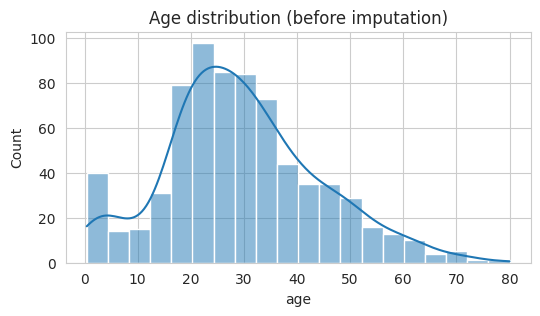

Mean age: 29.64
Median age: 28.0


In [9]:
# Check age distribution to decide between mean and median
plt.figure(figsize=(6, 3))
sns.histplot(df["age"], kde=True)
plt.title("Age distribution (before imputation)")
plt.show()

print("Mean age:", df["age"].mean().round(2))
print("Median age:", df["age"].median().round(2))


In [10]:
# The distribution is slightly right-skewed -> median is a safer choice than mean for 'age'
df["age"] = df["age"].fillna(df["age"].median())

print("Remaining missing values in 'age':", df["age"].isnull().sum())


Remaining missing values in 'age': 0


**Mode imputation** works the same way but is used for categorical columns
(here there's nothing left to impute since we already dropped the 2 missing rows —
this cell shows the pattern you'd use if there were more):


In [11]:
# Pattern for mode imputation (categorical column) - shown for reference
example = sns.load_dataset("titanic")
example["embark_town"] = example["embark_town"].fillna(example["embark_town"].mode()[0])
example["embarked"] = example["embarked"].fillna(example["embarked"].mode()[0])

print("Missing values remaining:", example[["embark_town", "embarked"]].isnull().sum().sum())


Missing values remaining: 0


### 4.6 KNN Imputation

**Idea:** for a row with a missing value, find its *k* most similar rows (nearest neighbors, based on
the other columns) and fill the missing value using their average (numeric) or majority vote (categorical).

**Pros:** captures relationships between features, better than a single global mean/median.
**Cons:** slower on large datasets, sensitive to feature scale (scale your data first for best results),
doesn't work directly on non-numeric columns without encoding them first.


In [12]:
from sklearn.impute import KNNImputer

df_knn = sns.load_dataset("titanic").drop(columns=["deck"])

# KNNImputer needs numeric input - here we impute a single numeric column ('age')
imputer = KNNImputer(n_neighbors=5)   # look at the 5 most similar rows
df_knn["age"] = imputer.fit_transform(df_knn[["age"]])

print("Missing values in 'age' after KNN imputation:", df_knn["age"].isnull().sum())


Missing values in 'age' after KNN imputation: 0


### 4.7 Iterative / Regression Imputation (MICE)

**MICE (Multiple Imputation by Chained Equations)** models each column with missing values as a
function of *all other columns*, one column at a time, in a round-robin loop, refining the estimates
over several iterations. `scikit-learn`'s `IterativeImputer` implements this.

**Requirement:** all input columns must be numeric, so categorical columns need to be **encoded first**
(see Section 7) — this is a great example of why preprocessing steps are interconnected, not isolated.


In [13]:
from sklearn.experimental import enable_iterative_imputer   # required to unlock IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

df_mice = sns.load_dataset("titanic").drop(columns=["deck"])

# Step 1: label-encode categorical columns so IterativeImputer can use them as predictors
cat_cols = ["sex", "embarked", "who", "class", "embark_town", "alive"]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # LabelEncoder can't handle NaN directly, so we only encode the non-null rows
    non_null_mask = df_mice[col].notna()
    df_mice[col] = df_mice[col].astype(object)   # allow mixing in numeric codes + NaN
    df_mice.loc[non_null_mask, col] = le.fit_transform(df_mice.loc[non_null_mask, col])
    encoders[col] = le

# Step 2: run the iterative imputer over the whole (now-numeric) dataframe
numeric_df = df_mice.select_dtypes(include=[np.number])
imputer = IterativeImputer(max_iter=10, random_state=42)
imputed_array = imputer.fit_transform(numeric_df)
imputed_df = pd.DataFrame(imputed_array, columns=numeric_df.columns, index=numeric_df.index)

print("Missing values after MICE imputation:")
print(imputed_df.isnull().sum().sort_values(ascending=False))


Missing values after MICE imputation:
survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64


### 4.8 Random Forest Imputation (model-based)

**Idea:** treat the column with missing values as the *target* of a supervised model. Train a
`RandomForestRegressor` (or classifier for categorical targets) on the rows where the value is known,
then predict the missing rows. This can capture non-linear relationships that plain regression misses.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

df_rf = sns.load_dataset("titanic").drop(columns=["deck"])

# Encode categoricals first (Random Forest needs numeric input)
cat_cols = ["sex", "embarked", "who", "class", "embark_town", "alive"]
rf_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    mask = df_rf[col].notna()
    df_rf[col] = df_rf[col].astype(object)   # allow mixing in numeric codes + NaN
    df_rf.loc[mask, col] = le.fit_transform(df_rf.loc[mask, col])
    df_rf[col] = df_rf[col].astype(float)
    rf_encoders[col] = le

# Split rows into "age known" (to train on) and "age missing" (to predict)
known = df_rf[df_rf["age"].notna()]
missing = df_rf[df_rf["age"].isna()]

X_known = known.drop(columns=["age"])
y_known = known["age"]

# Train/validate the model just to sanity-check it before using it for real imputation
X_train, X_test, y_train, y_test = train_test_split(X_known, y_known, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
print("Validation R² score:", round(rf_model.score(X_test, y_test), 3))

# Refit on ALL known rows, then predict the missing ones
rf_model.fit(X_known, y_known)
predicted_ages = rf_model.predict(missing.drop(columns=["age"]))

df_rf.loc[df_rf["age"].isna(), "age"] = predicted_ages
print("\nMissing values in 'age' after Random Forest imputation:", df_rf["age"].isnull().sum())


Validation R² score: 0.332



Missing values in 'age' after Random Forest imputation: 0


### 4.9 Which imputation method should you actually use? (Decision guide)

| Situation | Recommended method |
|---|---|
| Column >50-60% missing | Drop the column |
| A handful of rows missing (<1%) | Drop the rows |
| Numeric column, missing at random, not skewed | Mean imputation |
| Numeric column, skewed or has outliers | Median imputation |
| Categorical column | Mode imputation |
| You have time/compute budget and features are correlated | KNN or Iterative (MICE) imputation |
| Complex non-linear relationships between features | Random Forest imputation |
| Deep, high-dimensional data (images, sensor arrays) | Autoencoder-based imputation (deep learning) |

**Rule of thumb for real projects:** start simple (median/mode). Only reach for KNN / MICE / Random
Forest if the missing column is important to your target and simple imputation visibly hurts model
performance.


<a id="5"></a>
## 5. Handling Outliers

### 5.1 Theory — what & why

An **outlier** is a data point that lies far away from the rest of the data. Outliers can be:

- **Genuine rare events** (a real $1M transaction among $50 average transactions)
- **Data errors** (age recorded as `500`)

Outliers matter because many models (linear regression, KNN, K-means, anything using distance or
squared error) are **very sensitive** to extreme values — a single outlier can distort a mean, a
regression line, or a distance calculation. Tree-based models (Random Forest, XGBoost) are naturally
more robust to outliers.

### 5.2 Types of Outliers

Not all outliers are the same — knowing the type helps you pick the right detection method.

**By how many variables are involved:**

| Type | Meaning | Example |
|---|---|---|
| **Univariate outlier** | Extreme in a single column, looked at alone | Age = 300 |
| **Multivariate outlier** | Only extreme when several columns are considered together | Age = 25 with Income = 5,000,000 (each value alone is plausible, the *combination* isn't) |

**By pattern (common in time-series/statistics):**

| Type | Meaning | Example |
|---|---|---|
| **Point (global) outlier** | A single value far from the rest of the *entire* dataset | One transaction of $1,000,000 among $10-$200 transactions |
| **Contextual outlier** | Normal in general, but unusual *given the context* | 35°C is normal in summer but an outlier for a winter day |
| **Collective outlier** | A group of points is unusual together, even if each point alone looks fine | A sudden short burst of unusually high server traffic |

In practice, most day-to-day preprocessing deals with **univariate/point outliers** (Z-score, IQR — Sections
5.4–5.5 below); **multivariate/collective outliers** need model-based methods (Isolation Forest,
clustering — Section 5.6); **contextual outliers** usually need domain knowledge or time-aware features
(e.g. comparing a value to the same month last year) rather than a single global rule.

### 5.3 Step 1 — Detect outliers visually first

Always *look* at your data before applying a statistical rule.


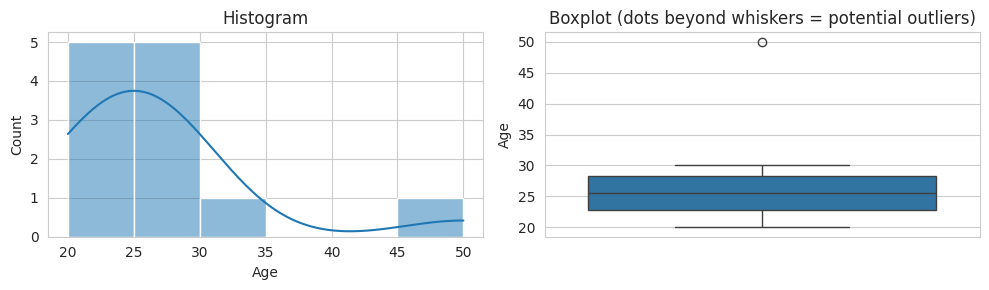

In [15]:
# A small synthetic example so the outlier is obvious to see
data = pd.DataFrame({"Age": [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 50]})

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(data["Age"], bins=6, kde=True, ax=axes[0])
axes[0].set_title("Histogram")
sns.boxplot(data=data, y="Age", ax=axes[1])
axes[1].set_title("Boxplot (dots beyond whiskers = potential outliers)")
plt.tight_layout()
plt.show()


### 5.4 Z-Score Method

The **Z-score** measures how many standard deviations a point is from the mean:

`z = (x − mean) / std`

**Rule of thumb:** a common threshold is `|z| > 3` (roughly 99.7% of normal data falls within 3 std
devs). This method assumes data is roughly **normally distributed** — it's less reliable on skewed data.


In [16]:
data["mean"] = data["Age"].mean()
data["std"] = data["Age"].std()
data["z_score"] = (data["Age"] - data["mean"]) / data["std"]
print(data)

threshold = 3
outliers = data[data["z_score"].abs() > threshold]
print("\nOutliers detected (|z| > 3):\n", outliers)


    Age       mean       std   z_score
0    20  27.083333  7.879298 -0.898980
1    21  27.083333  7.879298 -0.772065
2    22  27.083333  7.879298 -0.645151
3    23  27.083333  7.879298 -0.518236
4    24  27.083333  7.879298 -0.391321
5    25  27.083333  7.879298 -0.264406
6    26  27.083333  7.879298 -0.137491
7    27  27.083333  7.879298 -0.010576
8    28  27.083333  7.879298  0.116339
9    29  27.083333  7.879298  0.243253
10   30  27.083333  7.879298  0.370168
11   50  27.083333  7.879298  2.908466

Outliers detected (|z| > 3):
 Empty DataFrame
Columns: [Age, mean, std, z_score]
Index: []


In [17]:
# Remove the detected outliers
clean_data = data[data["z_score"].abs() <= threshold]
print("Before:", data.shape[0], "rows  |  After removing outliers:", clean_data.shape[0], "rows")


Before: 12 rows  |  After removing outliers: 12 rows


### 5.5 IQR (Interquartile Range) Method

The **IQR method** doesn't assume normality, so it's usually the **safer default** for skewed
real-world data. It uses the middle 50% of the data:

```
IQR = Q3 - Q1
Lower bound = Q1 - 1.5 * IQR
Upper bound = Q3 + 1.5 * IQR
```

Any value outside `[Lower bound, Upper bound]` is flagged as an outlier. This is exactly the rule
matplotlib/seaborn boxplots use to draw their whiskers.


In [18]:
data2 = pd.DataFrame({"Age": [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 50]})

Q1 = data2["Age"].quantile(0.25)
Q3 = data2["Age"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1}, Q3={Q3}, IQR={IQR}")
print(f"Valid range: [{lower_bound}, {upper_bound}]")

outliers_iqr = data2[(data2["Age"] < lower_bound) | (data2["Age"] > upper_bound)]
print("\nOutliers detected by IQR method:\n", outliers_iqr)


Q1=22.75, Q3=28.25, IQR=5.5
Valid range: [14.5, 36.5]

Outliers detected by IQR method:
     Age
11   50


### 5.6 Model-based detection: Isolation Forest & Clustering

For **multivariate outliers** (a point that's only unusual when you look at *combinations* of
columns together, not any single column alone), use model-based methods:

- **Isolation Forest**: isolates points using random splits — outliers get isolated in fewer splits
- **K-Means clustering**: points far from every cluster center are flagged as outliers
- **DBSCAN**: points that don't belong to any dense cluster are automatically labeled as noise/outliers


In [19]:
from sklearn.ensemble import IsolationForest

# Multivariate example: two columns together, where no single column looks extreme alone
multi_data = pd.DataFrame({
    "feature_1": [2, 3, 3, 4, 30, 3, 2, 4, 31, 3],
    "feature_2": [2, 3, 4, 3, 30, 4, 3, 3, 31, 4],
})

iso_forest = IsolationForest(contamination=0.2, random_state=42)   # contamination = expected % outliers
multi_data["is_outlier"] = iso_forest.fit_predict(multi_data[["feature_1", "feature_2"]])
# fit_predict returns -1 for outliers, 1 for normal points
multi_data["is_outlier"] = multi_data["is_outlier"].map({1: "normal", -1: "outlier"})
multi_data


,feature_1,feature_2,is_outlier
0,2,2,normal
1,3,3,normal
2,3,4,normal
3,4,3,normal
4,30,30,outlier
5,3,4,normal
6,2,3,normal
7,4,3,normal
8,31,31,outlier
9,3,4,normal


### 5.7 What to do once you've found outliers (Treatment options)

Finding outliers is only half the job — you then need to decide what to *do* with them:

| Treatment | When to use it |
|---|---|
| **Remove the rows** | Outlier is clearly a data-entry error and you have enough data to spare |
| **Cap / Winsorize** (clip to the boundary value instead of the true value) | You want to keep the row but limit its influence |
| **Transform the whole column** (log, Box-Cox — see Section 6) | Outliers come from natural skew (e.g. income, prices) rather than errors |
| **Keep as-is + use a robust model/scaler** | Outlier is a genuine rare event that matters for your business problem |
| **Treat as a separate flag/feature** | The *fact* that something is extreme is itself useful information |

Example — **capping (winsorizing)** instead of deleting:


In [20]:
data3 = pd.DataFrame({"Age": [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 50]})

Q1, Q3 = data3["Age"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

# Instead of deleting the row, clip the value to the nearest valid boundary
data3["Age_capped"] = data3["Age"].clip(lower=lower, upper=upper)
data3


,Age,Age_capped
0,20,20.0
1,21,21.0
2,22,22.0
3,23,23.0
4,24,24.0
5,25,25.0
6,26,26.0
7,27,27.0
8,28,28.0
9,29,29.0


### 5.8 Outlier detection method comparison

| Method | Assumes normal distribution? | Works on multiple columns at once? | Best for |
|---|---|---|---|
| Z-score | Yes | No (per-column) | Roughly normal, single-column numeric data |
| IQR | No | No (per-column) | Skewed, real-world single-column data (most common default) |
| Isolation Forest | No | Yes | Multivariate outliers, high-dimensional data |
| K-Means / DBSCAN | No | Yes | Cluster-shaped data where "far from any group" = outlier |


<a id="6"></a>
## 6. Feature Scaling & Transformation

### 6.1 Why scale features at all?

Many ML algorithms compare features using **distance** or **magnitude**
(KNN, K-Means, SVM, PCA, gradient descent–based models like Linear/Logistic Regression, Neural Networks).
If `income` ranges 0–200,000 and `age` ranges 0–100, `income` will completely dominate any distance
calculation just because of its scale — not because it's actually more important.

**Tree-based models (Decision Tree, Random Forest, XGBoost, LightGBM) do NOT require scaling** — they
split on thresholds per feature, so scale doesn't affect them. Still common in industry pipelines for
consistency, but it's not mathematically necessary for trees.

### 6.2 The four common scikit-learn scalers


In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler

sample = pd.DataFrame({
    "age":    [25, 30, 35, 40, 45],
    "height": [165, 170, 175, 180, 185],
    "weight": [55, 60, 65, 70, 75],
})
sample


,age,height,weight
0,25,165,55
1,30,170,60
2,35,175,65
3,40,180,70
4,45,185,75


**1. StandardScaler** — centers data around mean 0 with standard deviation 1:

`z = (x − mean) / std`

Best default choice for most linear models, SVM, and neural networks. Assumes no extreme outliers
(since mean/std are both sensitive to outliers).


In [22]:
scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(sample), columns=sample.columns)
scaled


,age,height,weight
0,-1.414214,-1.414214,-1.414214
1,-0.707107,-0.707107,-0.707107
2,0.000000,0.000000,0.000000
3,0.707107,0.707107,0.707107
4,1.414214,1.414214,1.414214


**2. MinMaxScaler** — squashes every value into a fixed range, usually `[0, 1]`:

`x_scaled = (x − min) / (max − min)`

Good when you need bounded values (e.g. for neural network inputs, or image pixel-like data).
Very sensitive to outliers, since a single extreme min/max stretches everything else into a tiny range.


In [23]:
scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(sample), columns=sample.columns)
scaled


,age,height,weight
0,0.00,0.00,0.00
1,0.25,0.25,0.25
2,0.50,0.50,0.50
3,0.75,0.75,0.75
4,1.00,1.00,1.00


**3. MaxAbsScaler** — divides by the maximum absolute value, so results land in `[-1, 1]`:

`x_scaled = x / max(|x|)`

Useful for **sparse data** (lots of zeros, e.g. text/TF-IDF features) because it doesn't shift/center
the data (zeros stay zero).


In [24]:
scaler = MaxAbsScaler()
scaled = pd.DataFrame(scaler.fit_transform(sample), columns=sample.columns)
scaled


,age,height,weight
0,0.555556,0.891892,0.733333
1,0.666667,0.918919,0.800000
2,0.777778,0.945946,0.866667
3,0.888889,0.972973,0.933333
4,1.000000,1.000000,1.000000


**4. RobustScaler** — uses the **median** and **IQR** instead of mean/std:

`x_scaled = (x − median) / IQR`

**The scaler to reach for when your data has outliers** — median and IQR aren't dragged around by
extreme values the way mean and std are.


In [25]:
scaler = RobustScaler()
scaled = pd.DataFrame(scaler.fit_transform(sample), columns=sample.columns)
scaled


,age,height,weight
0,-1.0,-1.0,-1.0
1,-0.5,-0.5,-0.5
2,0.0,0.0,0.0
3,0.5,0.5,0.5
4,1.0,1.0,1.0


### 6.3 Normalization (row-wise, not column-wise!)

⚠️ **Important distinction:** the scalers above work **column-wise** (each feature independently).
**Normalization** (`Normalizer` in scikit-learn) works **row-wise** — it rescales each *sample* (row)
to have unit norm. This is common for text data (TF-IDF vectors) and any case where the *direction*
of a vector matters more than its raw magnitude.

- **L2 normalization**: divide each row by its Euclidean length → `sqrt(sum(x_i²)) = 1`
- **L1 normalization**: divide each row by the sum of absolute values → `sum(|x_i|) = 1`


In [26]:
from sklearn.preprocessing import Normalizer

row_data = [[1, 1, 1], [1, 1, 0], [1, 0, 0]]

l2_normalizer = Normalizer(norm="l2")
print("L2 normalized (unit Euclidean length per row):\n", l2_normalizer.fit_transform(row_data))

l1_normalizer = Normalizer(norm="l1")
print("\nL1 normalized (absolute values sum to 1 per row):\n", l1_normalizer.fit_transform(row_data))


L2 normalized (unit Euclidean length per row):
 [[0.57735027 0.57735027 0.57735027]
 [0.70710678 0.70710678 0.        ]
 [1.         0.         0.        ]]

L1 normalized (absolute values sum to 1 per row):
 [[0.33333333 0.33333333 0.33333333]
 [0.5        0.5        0.        ]
 [1.         0.         0.        ]]


### 6.4 Fixing skewed distributions: Log & Power Transforms

Scaling changes the *range* of data but not its *shape*. If a column is heavily **skewed**
(e.g. income, prices, population), many models perform better if you first make the distribution
more symmetric/normal-like.

**Log transform** — simple, works well for positive, right-skewed data:


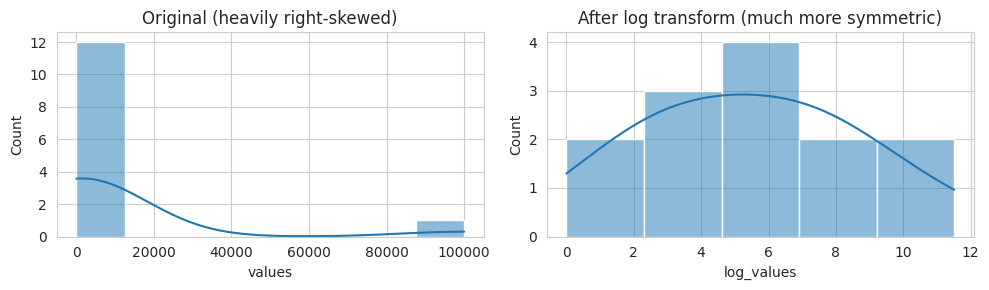

In [27]:
skewed = pd.DataFrame({"values": [1, 5, 10, 20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 100000]})

skewed["log_values"] = np.log(skewed["values"])

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
sns.histplot(skewed["values"], kde=True, ax=axes[0])
axes[0].set_title("Original (heavily right-skewed)")
sns.histplot(skewed["log_values"], kde=True, ax=axes[1])
axes[1].set_title("After log transform (much more symmetric)")
plt.tight_layout()
plt.show()


**Power transforms** — more flexible, automatically find the best transformation:

- **Box-Cox**: only works on strictly positive data
- **Yeo-Johnson**: works on positive, negative, and zero values (more flexible, usually the safer default)
- **Quantile transform**: forces the data into a uniform or normal distribution directly, non-parametrically


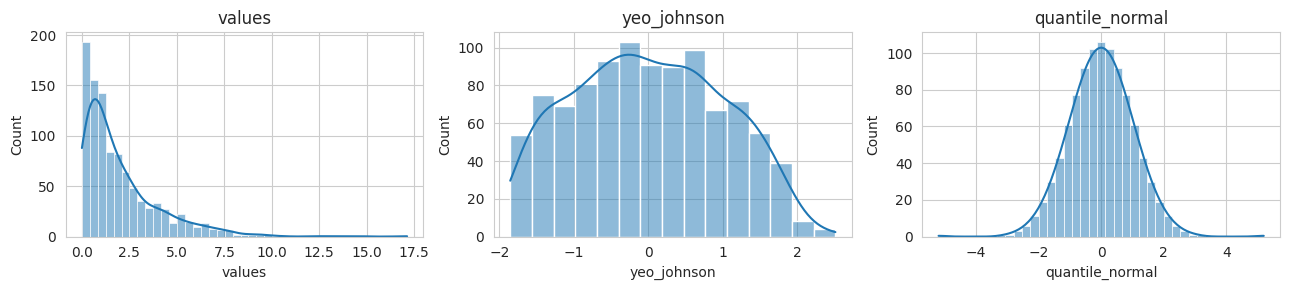

In [28]:
from sklearn.preprocessing import PowerTransformer, QuantileTransformer

np.random.seed(0)
exp_data = pd.DataFrame(np.random.exponential(size=1000, scale=2), columns=["values"])

pt_yeo = PowerTransformer(method="yeo-johnson")
qt_normal = QuantileTransformer(output_distribution="normal", random_state=0)

exp_data["yeo_johnson"] = pt_yeo.fit_transform(exp_data[["values"]])
exp_data["quantile_normal"] = qt_normal.fit_transform(exp_data[["values"]])

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, col in zip(axes, exp_data.columns):
    sns.histplot(exp_data[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 6.5 Practical Tips about Feature Scaling

A few things that trip people up in real projects:

- **Fit on train, transform on test — never the other way round, and never fit on both combined.**
  The scaler's mean/std (or min/max, or median/IQR) must come only from training data (Section 8
  shows the correct pattern).
- **Scale numeric columns only** — never scale one-hot encoded (0/1) columns or the target variable
  for classification. For regression targets, scaling the target is sometimes done but must be
  inverse-transformed before reporting results.
- **Distance-based and gradient-based models need scaling**: KNN, K-Means, SVM, PCA, Linear/Logistic
  Regression, Neural Networks. **Tree-based models don't**: Decision Tree, Random Forest, XGBoost,
  LightGBM, CatBoost — they split on raw thresholds, so scale is irrelevant to them.
- **Save the fitted scaler** (e.g. with `joblib.dump`) alongside your model — at prediction time on
  new data you must reuse the exact same fitted scaler, not fit a new one.
- **Outliers first, then scale** — if you plan to remove/cap outliers (Section 5), do that before
  fitting `StandardScaler`/`MinMaxScaler`, since both are sensitive to extreme values. If you can't
  remove outliers, prefer `RobustScaler`.
- **Re-check distributions after transforming** — always plot a histogram after applying a log/power
  transform to confirm it actually improved the shape, rather than assuming it did.

### 6.6 Which scaler/transform should you use? (Decision guide)

| Situation | Recommended technique |
|---|---|
| General-purpose default, no major outliers | `StandardScaler` |
| Need values bounded in `[0, 1]` (e.g. neural net input) | `MinMaxScaler` |
| Sparse data with many zeros | `MaxAbsScaler` |
| Data has significant outliers | `RobustScaler` |
| Row/vector direction matters more than magnitude (text, embeddings) | `Normalizer` (L1/L2) |
| Column is heavily right-skewed, all positive | Log transform or `PowerTransformer(method="box-cox")` |
| Column is skewed with zero/negative values | `PowerTransformer(method="yeo-johnson")` |
| Tree-based model (Random Forest, XGBoost) | Scaling usually **not required** at all |

**Golden rule:** `fit` the scaler only on training data, then `transform` (not `fit_transform`) the
test data with the same fitted scaler — otherwise information from the test set leaks into training
(see Section 8).


<a id="7"></a>
## 7. Feature Encoding (Categorical → Numeric)

### 7.1 Theory — what & why

ML algorithms need numbers, not text. **Feature encoding** converts categorical columns
(`"Male"/"Female"`, `"Mon"/"Tue"/"Wed"`) into numeric form. The *right* choice of encoding depends
on whether the categories have a natural order, how many unique categories exist, and which
model you plan to use.


In [29]:
tips = sns.load_dataset("tips")
tips.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 7.2 Label Encoding

Assigns each category an arbitrary integer (`0, 1, 2, ...`). **Best for binary categories** (only 2
possible values) since there's no false sense of order. ⚠️ For 3+ unordered categories, label encoding
can mislead linear models into thinking `2 > 1 > 0`, implying an order that doesn't exist.


In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
tips["time_encoded"] = le.fit_transform(tips["time"])   # 'Lunch'/'Dinner' -> 0/1, a clean binary case
print("Classes found:", le.classes_)
tips[["time", "time_encoded"]].drop_duplicates()


Classes found: ['Dinner' 'Lunch']


,time,time_encoded
0,Dinner,0
77,Lunch,1


### 7.3 Ordinal Encoding

Use when categories **do** have a natural order, and you explicitly tell the encoder that order.


In [31]:
from sklearn.preprocessing import OrdinalEncoder

# Example: if 'day' had a meaningful sequence (it doesn't strongly here, but this is the pattern)
oe = OrdinalEncoder(categories=[["Thur", "Fri", "Sat", "Sun"]])
tips["day_ordinal"] = oe.fit_transform(tips[["day"]])
tips[["day", "day_ordinal"]].drop_duplicates().sort_values("day_ordinal")


,day,day_ordinal
77,Thur,0.0
90,Fri,1.0
19,Sat,2.0
0,Sun,3.0


### 7.4 One-Hot Encoding

Creates one new binary (0/1) column per category — **no false order is implied**. This is the
**default safe choice** for unordered categorical columns, especially for linear/distance-based
models. ⚠️ Downside: creates many new columns if a feature has high cardinality (many unique values),
which can bloat your dataset ("the curse of dimensionality").


In [32]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
sex_encoded = ohe.fit_transform(tips[["sex"]])
sex_encoded_df = pd.DataFrame(sex_encoded, columns=ohe.get_feature_names_out(["sex"]))
sex_encoded_df.head()


,sex_Female,sex_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0


The pandas equivalent, `pd.get_dummies`, is quicker for one-off exploratory work:


In [33]:
dummies = pd.get_dummies(tips, columns=["day"])
dummies.filter(like="day").head()


,day_ordinal,day_Thur,day_Fri,day_Sat,day_Sun
0,3.0,False,False,False,True
1,3.0,False,False,False,True
2,3.0,False,False,False,True
3,3.0,False,False,False,True
4,3.0,False,False,False,True


### 7.5 Binary Encoding

A hybrid: converts categories to integers, then those integers to **binary digits**, spread across
`log2(n_categories)` columns. Good middle ground for **high-cardinality** columns (many unique
categories) where one-hot encoding would create too many columns.


In [34]:
from category_encoders import BinaryEncoder

binary_encoder = BinaryEncoder()
time_binary = binary_encoder.fit_transform(tips["time"])
time_binary.head()


,time_0,time_1
0,0,1
1,0,1
2,0,1
3,0,1
4,0,1


### 7.6 Manual Mapping

When you know exactly what numeric value each category should map to (based on domain knowledge),
a plain dictionary mapping is often the clearest, most transparent option.


In [35]:
tips["day_manual"] = tips["day"].map({"Thur": 0, "Fri": 1, "Sat": 2, "Sun": 3})
tips[["day", "day_manual"]].drop_duplicates().sort_values("day_manual")


,day,day_manual
77,Thur,0
90,Fri,1
19,Sat,2
0,Sun,3


### 7.7 Which encoder should you use? (Decision guide)

| Situation | Recommended encoding |
|---|---|
| Exactly 2 categories (binary) | Label Encoding |
| Categories have a genuine order (e.g. `low < medium < high`) | Ordinal Encoding |
| Unordered categories, low cardinality (< ~10 unique values) | One-Hot Encoding (`pd.get_dummies` / `OneHotEncoder`) |
| Unordered categories, high cardinality (many unique values) | Binary Encoding, or Frequency/Target Encoding |
| You know the exact mapping from domain knowledge | Manual mapping |
| Tree-based models (Random Forest, XGBoost, LightGBM) | Label Encoding is often fine — trees split per-category, order doesn't mislead them the way it does linear models |

⚠️ **Common pitfall:** fitting an encoder on the *whole* dataset (train + test combined) leaks
information and can hide the fact that the test set has categories your training data never saw.
Always fit encoders on training data only (Section 8 shows the correct pattern), and decide up front
how to handle categories that appear only at prediction time (e.g. `OneHotEncoder(handle_unknown="ignore")`).


<a id="8"></a>
## 8. Putting It All Together — A Real End-to-End Pipeline

Everything above was shown step-by-step for learning. In a real project you almost never want to
manually chain `fillna` → `scale` → `encode` by hand — it's error-prone and, critically, it's very
easy to accidentally leak test-set information into training.

The professional, production-safe approach:

1. **Split the data first** — before fitting anything
2. Build a `ColumnTransformer` that applies the right preprocessing to the right columns
3. Wrap it in a `Pipeline` together with the model
4. `fit` the whole pipeline on training data only; `transform`/`predict` on test data

This guarantees every imputer, scaler, and encoder is **fit only on the training set**, then reused
(not refit) on the test set — the correct way to prevent data leakage.


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------------
# 1. Load raw data and separate features (X) from the target (y)
# ---------------------------------------------------------------
raw = sns.load_dataset("titanic").drop(columns=["deck", "alive", "who", "adult_male", "embark_town"])
# 'alive'/'who'/'adult_male' leak the target or duplicate info - dropped as a modeling choice, not a preprocessing rule

X = raw.drop(columns=["survived"])
y = raw["survived"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# ---------------------------------------------------------------
# 2. Split BEFORE fitting any preprocessing step (avoids data leakage)
# ---------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("\nTrain shape:", X_train.shape, " Test shape:", X_test.shape)


Numeric features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
Categorical features: ['sex', 'embarked', 'class']

Train shape: (712, 9)  Test shape: (179, 9)


In [37]:
# ---------------------------------------------------------------
# 3. Define a preprocessing pipeline for each column type
# ---------------------------------------------------------------

# Numeric columns: impute missing values with median, then scale
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical columns: impute missing values with the most frequent category, then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),   # ignore unseen categories at test time
])

# ColumnTransformer applies the right pipeline to the right set of columns
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

# ---------------------------------------------------------------
# 4. Combine preprocessing + model into one full pipeline
# ---------------------------------------------------------------
full_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000)),
])

full_pipeline


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tr

In [38]:
# ---------------------------------------------------------------
# 5. Fit on TRAIN ONLY, then evaluate on TEST
# ---------------------------------------------------------------
full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)

print("Test accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Test accuracy: 0.804

Classification report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



**What just happened, in plain English:**

- The `SimpleImputer` for `age`/`fare` computed the **median from `X_train` only** and reused that
  same number to fill `X_test` — the test set never influenced the fill value.
- The `StandardScaler` computed **mean/std from `X_train` only** and applied that same scale to `X_test`.
- The `OneHotEncoder` learned its category list from `X_train` only, and safely ignores any category
  it hasn't seen before if it shows up in `X_test` (`handle_unknown="ignore"`).
- All of this happened in **one `.fit()` call** — no risk of forgetting a step or leaking information.

This is the pattern you should use for almost every real ML project.


<a id="9"></a>
## 9. Preprocessing Checklist & Common Pitfalls

### ✅ The checklist

- [ ] Explored the data (`.info()`, `.describe()`, `.isnull().sum()`, `.duplicated().sum()`)
- [ ] Removed duplicate rows
- [ ] Fixed obviously wrong data types (e.g. numbers stored as text)
- [ ] Decided a strategy for every column with missing values (drop / mean / median / mode / model-based)
- [ ] Checked numeric columns for outliers (boxplot + IQR or Z-score) and decided how to treat them
- [ ] Split data into train/test **before** fitting any imputer/scaler/encoder
- [ ] Scaled numeric features appropriately for the chosen model
- [ ] Encoded every categorical column appropriately for its cardinality and ordinality
- [ ] Verified the final feature matrix contains only numbers, and has no `NaN` left
- [ ] Saved/serialized the fitted preprocessing pipeline (e.g. with `joblib`) so the exact same
      transformations can be applied to new, unseen data later

### ⚠️ Common pitfalls

1. **Data leakage** — fitting a scaler/imputer/encoder on the full dataset (train + test) instead of
   train only. This silently inflates your reported model performance.
2. **Deleting too much data** — dropping every row with any missing value can throw away a large,
   useful chunk of your dataset. Check *how much* you'd lose before doing this.
3. **Using mean imputation on skewed data** — the mean is pulled toward outliers; median is safer.
4. **One-hot encoding a high-cardinality column** — a `city` column with 5,000 unique values creates
   5,000 new columns. Consider binary/frequency/target encoding instead.
5. **Scaling before splitting train/test** — always split first.
6. **Ignoring *why* data is missing** — sometimes "missing" itself is informative (e.g. a customer who
   didn't fill in `income` might be systematically different) — consider adding a `was_missing` flag
   column in addition to imputing.
7. **Forgetting to apply the exact same preprocessing to new/production data** — this is why
   pipelines (Section 8) are so valuable: they package every step into one reusable object.


<a id="10"></a>
## 10. Practice Exercises

Try these on your own — using the `titanic` and `tips` datasets from this notebook, or better yet,
a dataset of your own from [Kaggle](https://www.kaggle.com/datasets):

1. **Missing values:** Load the `titanic` dataset fresh. Impute `age` using KNN imputation with
   `n_neighbors=3`, `n_neighbors=7`, and `n_neighbors=15`. Plot the resulting `age` distribution for
   each and compare to the original. Which `k` best preserves the original distribution's shape?

2. **Outliers:** Using the `tips` dataset, detect outliers in the `total_bill` column using both the
   Z-score method and the IQR method. Do they flag the same rows? Which method do you trust more here,
   and why?

3. **Scaling:** Take the `fare` column from `titanic` (it's heavily right-skewed). Apply
   `StandardScaler`, `MinMaxScaler`, and `RobustScaler` to it, then plot histograms of each result
   side by side. Which scaler handles the skew/outliers most gracefully?

4. **Encoding:** The `tips` dataset has a `day` column with 4 categories. Encode it three different
   ways — Label Encoding, One-Hot Encoding, and Binary Encoding — and compare how many columns each
   approach produces. Which would you choose if `day` instead had 50 unique values?

5. **Full pipeline (capstone):** Pick any dataset with at least one missing-value column, one skewed
   numeric column, and one categorical column. Build a complete `ColumnTransformer` + `Pipeline` (like
   Section 8), fit it on a training split, and report accuracy/appropriate metric on a held-out test
   split. Then deliberately introduce a category value in your test set that didn't exist in
   training — confirm your pipeline handles it gracefully instead of crashing.

---

### 📌 Quick-reference: what goes where

| Task | Tool |
|---|---|
| Detect missing values | `df.isnull().sum()` |
| Simple imputation | `SimpleImputer` / `.fillna()` |
| Smart imputation | `KNNImputer`, `IterativeImputer` |
| Detect outliers | Boxplot, Z-score, IQR, `IsolationForest` |
| Treat outliers | `.clip()`, remove rows, transform, robust model |
| Scale features | `StandardScaler`, `MinMaxScaler`, `MaxAbsScaler`, `RobustScaler` |
| Normalize rows | `Normalizer` (L1/L2) |
| Fix skew | `np.log`, `PowerTransformer`, `QuantileTransformer` |
| Encode categories | `LabelEncoder`, `OrdinalEncoder`, `OneHotEncoder`, `pd.get_dummies`, `BinaryEncoder` |
| Chain it all safely | `ColumnTransformer` + `Pipeline` |

**Happy preprocessing! 🚀** The cleaner your data, the better every model you build on top of it will be.
